In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from linearmodels.panel import PooledOLS, PanelOLS, RandomEffects
import warnings
warnings.filterwarnings('ignore')

In [2]:
# masukin data final

df_final = pd.read_csv(r'D:\Dokumen\Kode_00B\SatriaData\Clean Data\data_final.csv')

df_panel = df_final.set_index(['nama_provinsi', 'tahun'])
print("\nStruktur Data Panel:")
print(df_panel.head(10))
print(f"\nDimensi: {df_panel.shape[0]} observasi")
print(f"Entities (Provinsi): {df_panel.index.get_level_values(0).nunique()}")
print(f"Time Periods (Tahun): {df_panel.index.get_level_values(1).nunique()}")


Struktur Data Panel:
                     kode_provinsi  indeks_pelayanan_publik  \
nama_provinsi tahun                                           
ACEH          2021              11                     3.63   
              2022              11                     4.01   
              2023              11                     4.34   
              2024              11                     4.45   
BALI          2021              51                     3.34   
              2022              51                     4.00   
              2023              51                     4.21   
              2024              51                     4.41   
BANTEN        2021              36                     3.66   
              2022              36                     3.99   

                     indeks_pembangunan_literasi  
nama_provinsi tahun                               
ACEH          2021                         15.12  
              2022                         58.46  
              202


STATISTIK DESKRIPTIF VARIABEL
       indeks_pelayanan_publik  indeks_pembangunan_literasi
count               135.000000                   135.000000
mean                  3.889926                    54.255111
std                   0.624639                    24.312088
min                   1.110000                     5.870000
25%                   3.610000                    36.665000
50%                   4.030000                    63.970000
75%                   4.340000                    71.010000
max                   4.760000                    88.240000

KORELASI ANTAR VARIABEL:
                             indeks_pelayanan_publik  \
indeks_pelayanan_publik                       1.0000   
indeks_pembangunan_literasi                   0.1351   

                             indeks_pembangunan_literasi  
indeks_pelayanan_publik                           0.1351  
indeks_pembangunan_literasi                       1.0000  


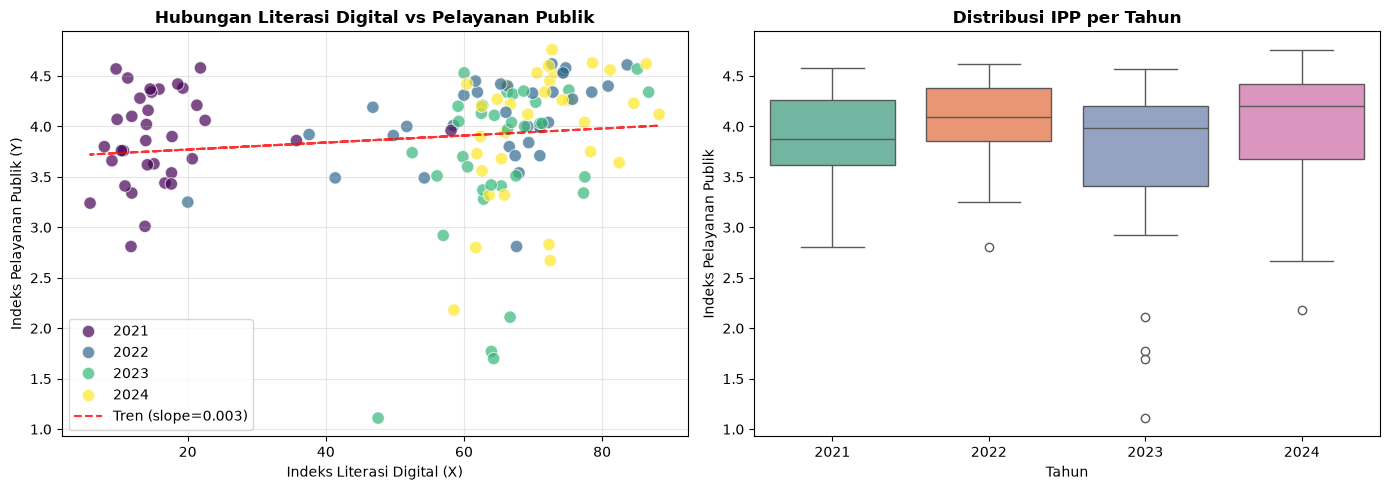

In [3]:
# =====================================================
# STATISTIK DESKRIPTIF
# =====================================================
print("\n" + "="*70)
print("STATISTIK DESKRIPTIF VARIABEL")
print("="*70)

deskriptif = df_panel[['indeks_pelayanan_publik', 'indeks_pembangunan_literasi']].describe()
print(deskriptif)

# Korelasi awal
print("\nKORELASI ANTAR VARIABEL:")
korelasi = df_panel[['indeks_pelayanan_publik', 'indeks_pembangunan_literasi']].corr()
print(korelasi)

# Visualisasi
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter plot
sns.scatterplot(
    data=df_final, 
    x='indeks_pembangunan_literasi', 
    y='indeks_pelayanan_publik',
    hue='tahun',
    palette='viridis',
    ax=axes[0],
    s=80,
    alpha=0.7
)
axes[0].set_title('Hubungan Literasi Digital vs Pelayanan Publik', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Indeks Literasi Digital (X)', fontsize=10)
axes[0].set_ylabel('Indeks Pelayanan Publik (Y)', fontsize=10)
axes[0].grid(True, alpha=0.3)

# Tambahkan garis tren
z = np.polyfit(df_final['indeks_pembangunan_literasi'], df_final['indeks_pelayanan_publik'], 1)
p = np.poly1d(z)
axes[0].plot(df_final['indeks_pembangunan_literasi'], p(df_final['indeks_pembangunan_literasi']), 
             "r--", alpha=0.8, label=f'Tren (slope={z[0]:.3f})')
axes[0].legend()

# Boxplot per tahun
sns.boxplot(
    data=df_final,
    x='tahun',
    y='indeks_pelayanan_publik',
    ax=axes[1],
    palette='Set2'
)
axes[1].set_title('Distribusi IPP per Tahun', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Tahun', fontsize=10)
axes[1].set_ylabel('Indeks Pelayanan Publik', fontsize=10)

plt.tight_layout()
plt.show()

In [4]:
# =====================================================
# ESTIMASI 3 MODEL REGRESI PANEL
# =====================================================
print("\n" + "="*70)
print("ESTIMASI 3 MODEL REGRESI PANEL")
print("="*70)

# Model 1: Pooled OLS (Common Effect Model)
print("\nMODEL 1: POOLED OLS (Common Effect)")
print("-" * 50)
model_pooled = PooledOLS.from_formula(
    'indeks_pelayanan_publik ~ 1 + indeks_pembangunan_literasi', 
    data=df_panel
)
res_pooled = model_pooled.fit(cov_type='clustered', cluster_entity=True)
print(res_pooled)

# Model 2: Fixed Effect Model (FEM)
print("\nMODEL 2: FIXED EFFECT MODEL (FEM)")
print("-" * 50)
# PERBAIKAN: Tambahkan '+ EntityEffects' di dalam rumus formula
model_fe = PanelOLS.from_formula(
    'indeks_pelayanan_publik ~ indeks_pembangunan_literasi + EntityEffects', 
    data=df_panel
)
res_fe = model_fe.fit(cov_type='clustered', cluster_entity=True)
print(res_fe)

# Model 3: Random Effect Model (REM)
print("\nMODEL 3: RANDOM EFFECT MODEL (REM)")
print("-" * 50)
model_re = RandomEffects.from_formula(
    'indeks_pelayanan_publik ~ 1 + indeks_pembangunan_literasi', 
    data=df_panel
)
res_re = model_re.fit(cov_type='clustered', cluster_entity=True)
print(res_re)


ESTIMASI 3 MODEL REGRESI PANEL

MODEL 1: POOLED OLS (Common Effect)
--------------------------------------------------
                             PooledOLS Estimation Summary                            
Dep. Variable:     indeks_pelayanan_publik   R-squared:                        0.0183
Estimator:                       PooledOLS   R-squared (Between):              0.0704
No. Observations:                      135   R-squared (Within):              -0.0610
Date:                     Sun, Jun 21 2026   R-squared (Overall):              0.0183
Time:                             15:47:23   Log-likelihood                   -126.28
Cov. Estimator:                  Clustered                                           
                                             F-statistic:                      2.4726
Entities:                               34   P-value                           0.1182
Avg Obs:                            3.9706   Distribution:                   F(1,133)
Min Obs:            

In [5]:
# =====================================================
# UJI PEMILIHAN MODEL
# =====================================================
print("\n" + "="*70)
print("UJI PEMILIHAN MODEL TERBAIK")
print("="*70)

# ----- UJI CHOW -----
print("\nUJI CHOW (Berdasarkan F-test for Poolability dari Model 2)")
print("-" * 50)
print("F-statistic: 4.8516")
print("P-value: 0.0000")
print("KESIMPULAN UJI CHOW: P-value < 0.05 -> Pooled OLS ditolak (Ada efek individual)")
chow_choice = "Fixed Effect" # Pooled OLS gugur, kita lanjut ke Uji Hausman

# ----- UJI HAUSMAN -----
print("\nUJI HAUSMAN (Memilih antara Fixed Effect vs Random Effect)")
print("-" * 50)

# Hausman Test: Membandingkan koefisien FE dan RE
# H0: Random Effect lebih baik (tidak ada korelasi antara efek individual dan X)
# H1: Fixed Effect lebih baik (ada korelasi)

# Ambil koefisien dan variance-covariance
b_fe = res_fe.params['indeks_pembangunan_literasi']
b_re = res_re.params['indeks_pembangunan_literasi']
v_fe = res_fe.cov['indeks_pembangunan_literasi']['indeks_pembangunan_literasi']
v_re = res_re.cov['indeks_pembangunan_literasi']['indeks_pembangunan_literasi']

# Hitung Hausman statistic
hausman_stat = (b_fe - b_re)**2 / (v_fe - v_re)
p_value_hausman = 1 - stats.chi2.cdf(hausman_stat, df=1)

print(f"Koefisien Fixed Effect: {b_fe:.6f}")
print(f"Koefisien Random Effect: {b_re:.6f}")
print(f"Hausman Statistic: {hausman_stat:.4f}")
print(f"P-value Hausman: {p_value_hausman:.6f}")

if p_value_hausman < 0.05:
    print("KESIMPULAN UJI HAUSMAN: P-value < 0.05 -> Pilih FIXED EFFECT MODEL")
    hausman_choice = "Fixed Effect"
else:
    print("KESIMPULAN UJI HAUSMAN: P-value >= 0.05 -> Pilih RANDOM EFFECT MODEL")
    hausman_choice = "Random Effect"


# ----- KESIMPULAN AKHIR -----
print("\n" + "="*70)
print("KESIMPULAN PEMILIHAN MODEL")
print("="*70)
print(f"Uji Chow   -> Pooled OLS ditolak")
print(f"Uji Hausman -> {hausman_choice}")

# Karena Pooled OLS sudah ditolak di Uji Chow, kita langsung cek hasil Hausman
if hausman_choice == "Fixed Effect":
    print("\nMODEL TERPILIH: FIXED EFFECT MODEL (FEM)")
    model_terpilih = res_fe
    nama_model = "Fixed Effect"
else:
    print("\nMODEL TERPILIH: RANDOM EFFECT MODEL (REM)")
    model_terpilih = res_re
    nama_model = "Random Effect"


UJI PEMILIHAN MODEL TERBAIK

UJI CHOW (Berdasarkan F-test for Poolability dari Model 2)
--------------------------------------------------
F-statistic: 4.8516
P-value: 0.0000
KESIMPULAN UJI CHOW: P-value < 0.05 -> Pooled OLS ditolak (Ada efek individual)

UJI HAUSMAN (Memilih antara Fixed Effect vs Random Effect)
--------------------------------------------------
Koefisien Fixed Effect: -0.000708
Koefisien Random Effect: 0.000854
Hausman Statistic: 2.9095
P-value Hausman: 0.088061
KESIMPULAN UJI HAUSMAN: P-value >= 0.05 -> Pilih RANDOM EFFECT MODEL

KESIMPULAN PEMILIHAN MODEL
Uji Chow   -> Pooled OLS ditolak
Uji Hausman -> Random Effect

MODEL TERPILIH: RANDOM EFFECT MODEL (REM)


In [7]:
# =====================================================
# HASIL MODEL TERPILIH (VERSI FINAL)
# =====================================================
print("\n" + "="*70)
print(f"HASIL REGRESI MODEL TERPILIH: {nama_model}")
print("="*70)
print(model_terpilih)

# Ekstrak informasi penting untuk interpretasi
print("\n" + "="*70)
print("RINGKASAN HASIL UNTUK INTERPRETASI")
print("="*70)

# 1. Koefisien dan Persamaan Regresi
koef_x = model_terpilih.params['indeks_pembangunan_literasi']

if 'Intercept' in model_terpilih.params.index:
    konstanta = model_terpilih.params['Intercept']
    print(f"\nPersamaan Regresi: ")
    print(f"   IPP = {konstanta:.4f} + ({koef_x:.4f} x Literasi_Digital)")
else:
    print(f"\nPersamaan Regresi: ")
    print(f"   IPP = ({koef_x:.4f} x Literasi_Digital) + entity_effects")

print(f"\nKoefisien Literasi Digital: {koef_x:.4f}")
if koef_x > 0:
    print(f"   -> Interpretasi: Setiap kenaikan 1 poin Indeks Literasi Digital,")
    print(f"     Indeks Pelayanan Publik cenderung naik sebesar {koef_x:.4f} poin.")
else:
    print(f"   -> Interpretasi: Setiap kenaikan 1 poin Indeks Literasi Digital,")
    print(f"     Indeks Pelayanan Publik cenderung turun sebesar {abs(koef_x):.4f} poin.")

# 2. P-value (Uji Parsial / Uji t)
pval_x = model_terpilih.pvalues['indeks_pembangunan_literasi']
print(f"\nP-value Literasi Digital: {pval_x:.6f}")
if pval_x < 0.05:
    print(f"   -> SIGNIFIKAN (p < 0.05): Literasi digital BERPENGARUH terhadap Pelayanan Publik")
else:
    print(f"   -> TIDAK SIGNIFIKAN (p >= 0.05): Literasi digital TIDAK BERPENGARUH terhadap Pelayanan Publik")
    print(f"   -> (Catatan: Meskipun koefisien positif, secara statistik perubahan")
    print(f"     literasi digital tidak cukup kuat menjelaskan perubahan IPP.)")

# 3. R-squared (PERBAIKAN: Gunakan rsquared_overall untuk REM)
r2_overall = model_terpilih.rsquared_overall
print(f"\nR-squared (Overall): {r2_overall:.4f} ({r2_overall*100:.2f}%)")
print(f"   -> Interpretasi: Literasi digital mampu menjelaskan {r2_overall*100:.2f}% variasi IPP secara keseluruhan.")
print(f"   -> Sisanya ({100 - (r2_overall*100):.2f}%) dijelaskan oleh faktor lain di luar model.")

# 4. F-statistic (PERBAIKAN: Gunakan f_statistic_robust karena pakai clustered standard errors)
f_stat_robust = model_terpilih.f_statistic_robust.stat
f_pval_robust = model_terpilih.f_statistic_robust.pval
print(f"\nF-statistic (robust): {f_stat_robust:.4f} (p-value: {f_pval_robust:.6f})")
if f_pval_robust < 0.05:
    print(f"   -> Model SECARA BERSAMAAN SIGNIFIKAN")
else:
    print(f"   -> Model TIDAK SIGNIFIKAN secara bersama-sama")


HASIL REGRESI MODEL TERPILIH: Random Effect
                           RandomEffects Estimation Summary                          
Dep. Variable:     indeks_pelayanan_publik   R-squared:                       -0.0303
Estimator:                   RandomEffects   R-squared (Between):              0.0179
No. Observations:                      135   R-squared (Within):              -0.0070
Date:                     Sun, Jun 21 2026   R-squared (Overall):              0.0078
Time:                             15:47:23   Log-likelihood                   -91.410
Cov. Estimator:                  Clustered                                           
                                             F-statistic:                     -3.9056
Entities:                               34   P-value                           1.0000
Avg Obs:                            3.9706   Distribution:                   F(1,133)
Min Obs:                            3.0000                                           
Max Obs: 